In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
outdir = '/work/submit/newolfe/tilts-and-kicks/data/synth'
outdir = f'{outdir}/SFH_rates_lab_populations'

path = f'{outdir}/1e-04_Zsun_population.h5'

df = pd.read_hdf(path, key='history')

In [38]:
with h5py.File(path, 'r') as f:
    print(f.keys())

<KeysViewHDF5 ['formation_channels', 'history', 'history_lengths', 'ini_parameters', 'mass_per_metallicity', 'oneline']>


In [40]:
df.loc[[0]]['S2_spin']

binary_index
0         NaN
0    4.682476
0    4.682476
0         NaN
0         NaN
0         NaN
Name: S2_spin, dtype: float64

In [58]:
np.unique(df['state'])

array(['ERR', 'RLO1', 'RLO2', 'contact', 'detached', 'disrupted',
       'initial_RLOF', 'merged'], dtype=object)

In [61]:
df['event'].unique()

array(['ZAMS', 'oCE1', 'oMerging1', 'CC1', nan, 'END', 'CC2', 'oCE2',
       'oMerging2', 'oRLO2', 'CO_contact', 'maxtime', 'oDoubleCE2',
       'oDoubleCE1', 'FAILED'], dtype=object)

In [84]:
mask = (df['S1_state'] == 'BH') & (df['S2_state'] == 'BH') & (df['event'] == 'CO_contact')
mbbh = df[mask]

ms1, ms2 = mbbh['S1_mass'], mbbh['S2_mass']
ms = np.column_stack((ms1, ms2))
ms = np.sort(ms, axis=-1)
m2, m1 = ms[:, 0], ms[:, 1]
q = m2 / m1

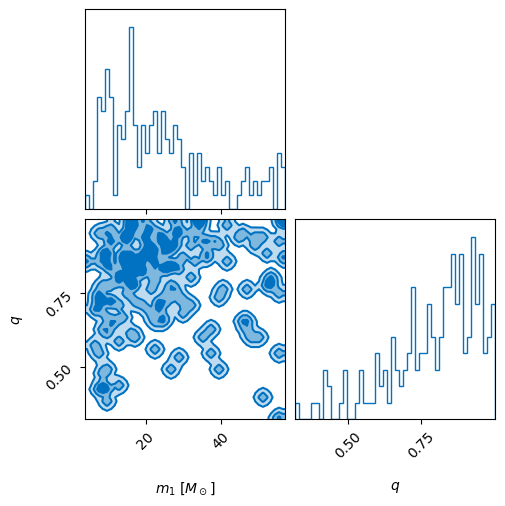

In [ ]:
from util import plot_corner

fig = plot_corner(
    np.column_stack((
        m1, q
    )),
    labels=[r'$m_1$ [$M_\odot$]', r'$q$']
)

In [118]:
import h5ify

import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

parentdir = '/work/submit/newolfe/tilts-and-kicks/data/vt/snr15'
allinj = h5ify.load(f'{parentdir}/ct-iso/all.hdf5')
det = h5ify.load(f'{parentdir}/ct-iso/detectable.hdf5')

In [115]:
from pixelpop.models.gwpop_models import BrokenPowerlawPlusTwoPeaks_PrimaryMass
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

ks = dict(histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), linewidth=3, density=True)

parameters = allinj['parameters']

m1s = jnp.linspace(3, 300, 1_000)
p_m1 = jnp.exp(BrokenPowerlawPlusTwoPeaks_PrimaryMass(
    dict(mass_1=m1s),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mmin=parameters['mmin'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(parameters['lam_0'], parameters['lam_1'], parameters['lam_2']),
    mpp_1=parameters['mpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_1=parameters['sigpp_1'],
    sigpp_2=parameters['sigpp_2'],
))

In [122]:
ks = dict(histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), linewidth=3, density=True)

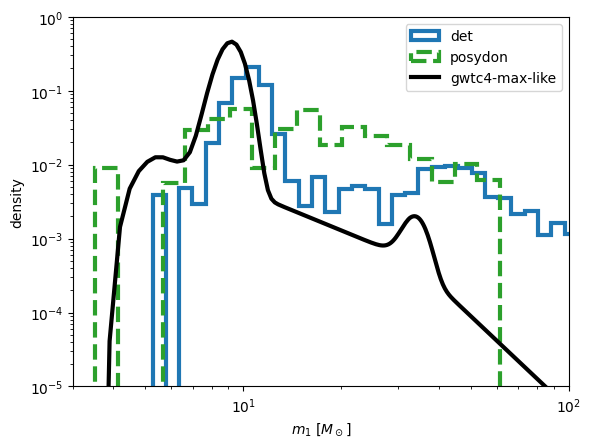

In [125]:
fig, ax = plt.subplots()
ax.hist(det['mass_1'], label='det', **ks)
ax.hist(m1, histtype='step', bins=np.logspace(np.log10(3), np.log10(300), 30), density=True, label='posydon', color='C2', linewidth=3, linestyle='--');
ax.plot(m1s, p_m1, linewidth=3, color='black', label='gwtc4-max-like')
ax.loglog()
ax.set_xlim(3, 100)
ax.set_ylim(1e-5, 1e0)
ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel('density')
ax.legend()
fig.savefig('../notes/figures/25-11-14/m1-posydon-gwtc4.pdf')

In [127]:
ks = dict(histtype='step', bins=jnp.linspace(0.1, 1, 50), linewidth=3, density=True)

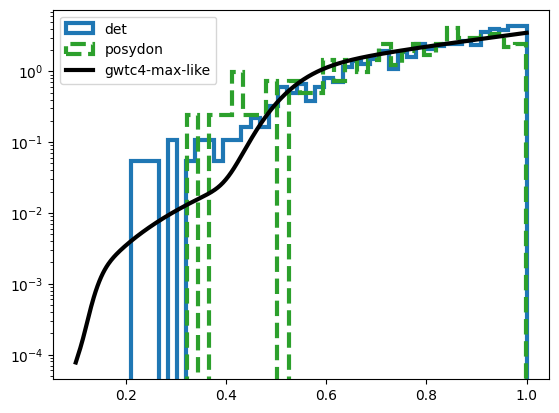

In [ ]:
m1s = jnp.linspace(3, 300, 500)
qs = jnp.linspace(0.1, 1, 500)

mm, qq = jnp.meshgrid(m1s, qs, indexing='ij')

def calc_p_q_marg_m1():
    log_p_q_given_m1 = PowerlawPlusPeak_MassRatio(
        dict(
            mass_1=mm,
            mass_ratio=qq
        ),
        slope=parameters['beta'],
        minimum=parameters['mmin'],
        delta_m=parameters['delta_m_1'] 
    )

    log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass(
        dict(mass_1=mm),
        alpha_1=parameters['alpha_1'],
        alpha_2=parameters['alpha_2'],
        mmin=parameters['mmin'],
        break_mass=parameters['break_mass'],
        delta_m_1=parameters['delta_m_1'],
        lam_fractions=(parameters['lam_0'], parameters['lam_1'], parameters['lam_2']),
        mpp_1=parameters['mpp_1'],
        mpp_2=parameters['mpp_2'],
        sigpp_1=parameters['sigpp_1'],
        sigpp_2=parameters['sigpp_2'],
    )

    log_p_m1q = log_p_m1 + log_p_q_given_m1
    
    return jnp.trapezoid(
        y=jnp.exp(log_p_m1q),
        x=m1s,
        axis=0
    )

p_q = calc_p_q_marg_m1()

fig, ax = plt.subplots()
ax.hist(det['mass_ratio'], label='det', **ks)
ax.hist(q, histtype='step', bins=30, color='C2', linestyle='--', density=True, label='posydon', linewidth=3);
ax.plot(qs, p_q, linewidth=3, color='black', label='gwtc4-max-like')
ax.set_yscale('log')
ax.legend()
fig.savefig('../notes/figures/25-11-14/q-posydon-gwtc4.pdf')